<a href="https://colab.research.google.com/github/SaymaSJ/Machine-learning-project/blob/main/predicting_diabetes_using_logistic_regression_and_compare_with_SVM%2CXGBOOst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import all the libraries

In [41]:
import numpy as np
import pandas as pd
import sklearn as linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

Mount the google drive

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
df=pd.read_csv("/content/drive/MyDrive/diabetes.csv") #load the dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [45]:
df.describe() #describe the dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [46]:
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


In [47]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [48]:
df.duplicated()
df.duplicated().sum()

np.int64(0)

# Train and test data split

In [49]:
x = df.drop('Outcome', axis=1)
y=df["Outcome"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
print(f"shape of x_train:{x_train.shape}")
print(f"shape of x_test:{x_test.shape}")
print(f"shape of y_train:{y_train.shape}")
print(f"shape of y_test:{y_test.shape}")



shape of x_train:(614, 8)
shape of x_test:(154, 8)
shape of y_train:(614,)
shape of y_test:(154,)


In [50]:
#Train model using x_train and y_train
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [51]:
y_pred=model.predict(x_test)
print(y_pred)

[0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 1 1 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


**Result**

In [52]:
Result=accuracy_score(y_test,y_pred)
print(f"Logistic Regression model accuracy: {Result:.4f}%")

Logistic Regression model accuracy: 0.7468%


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test ,y_pred))

[[78 21]
 [18 37]]


### Improving Model Recall for Class 1 (Diabetes)

To improve the model's ability to correctly identify instances of class 1 (recall), we can use resampling techniques to address potential class imbalance. If class 1 is underrepresented in the training data, the model might not learn its patterns effectively.

We will use `SMOTE` (Synthetic Minority Oversampling Technique) to create synthetic samples for the minority class, thereby balancing the dataset. First, let's install the necessary library.

In [55]:
pip install imbalanced-learn

In [56]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(f"Original training set shape: {x_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_train_smote.shape}, {y_train_smote.shape}")
print(f"Class distribution after SMOTE: {y_train_smote.value_counts()}")

Original training set shape: (614, 8), (614,)
Resampled training set shape: (802, 8), (802,)
Class distribution after SMOTE: Outcome
0    401
1    401
Name: count, dtype: int64


Now that the training data is balanced, let's retrain the `LogisticRegression` model with the resampled data and evaluate its performance again. We'll reuse the existing `LogisticRegression` model configuration but refit it to the new `X_train_smote` and `y_train_smote`.

In [57]:
# Retrain the model with SMOTE-resampled data
model_smote = LogisticRegression(max_iter=1000, random_state=42) # Re-initialize to ensure a fresh fit
model_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the original test set
y_pred_smote = model_smote.predict(x_test)

# Evaluate the new model
print("\n--- Model Performance After SMOTE ---")
print(classification_report(y_test, y_pred_smote))
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_smote)}")
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print(f"Logistic Regression model accuracy after SMOTE: {accuracy_smote:.4f}%")


--- Model Performance After SMOTE ---
              precision    recall  f1-score   support

           0       0.81      0.69      0.74        99
           1       0.56      0.71      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.70      0.68       154
weighted avg       0.72      0.69      0.70       154

Confusion Matrix:
[[68 31]
 [16 39]]
Logistic Regression model accuracy after SMOTE: 0.6948%


### Predict Diabetes for New Input

In [58]:
print("Please enter the patient's data for prediction:")

# Get new input from the user for each feature
new_pregnancies = float(input("Pregnancies: "))
new_glucose = float(input("Glucose: "))
new_bloodpressure = float(input("BloodPressure: "))
new_skinthickness = float(input("SkinThickness: "))
new_insulin = float(input("Insulin: "))
new_bmi = float(input("BMI: "))
new_dpf = float(input("DiabetesPedigreeFunction: "))
new_age = float(input("Age: "))

# Create a DataFrame from the new input
new_data = pd.DataFrame([[new_pregnancies, new_glucose, new_bloodpressure,
                          new_skinthickness, new_insulin, new_bmi,
                          new_dpf, new_age]],
                        columns=x.columns) # Use the original column names

# Apply the same feature engineering (replace 0s with medians) as done on the training data
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    if new_data[col][0] == 0: # Only replace if the input value is 0
        median_val = df_fe[col].median() # Use median from the feature-engineered df
        new_data[col] = median_val

print("\nPreprocessed input data:")
display(new_data)

# Make prediction using the retrained model (model_smote_fe)
prediction = model_smote_fe.predict(new_data)

# Interpret and display the prediction
if prediction[0] == 1:
    print("\nPrediction: The model predicts that the patient **has diabetes**.")
else:
    print("\nPrediction: The model predicts that the patient **does not have diabetes**.")

Please enter the patient's data for prediction:


KeyboardInterrupt: Interrupted by user

### Visualizing the Confusion Matrix after SMOTE

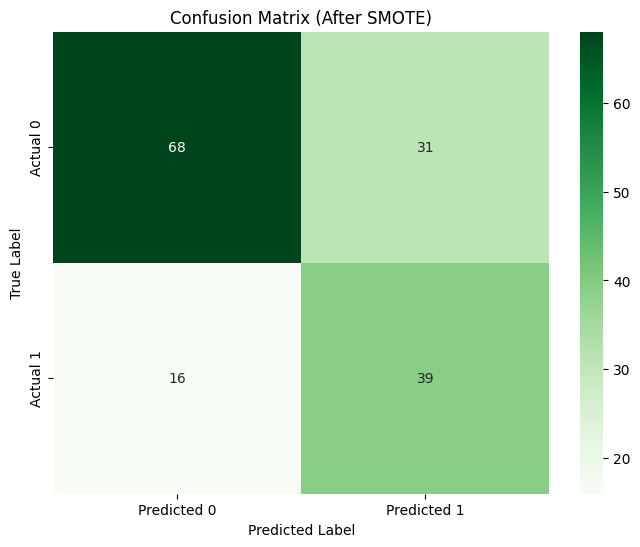

In [59]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (After SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Visualizing 'Glucose' and 'BMI' Distributions (Before Cleaning)

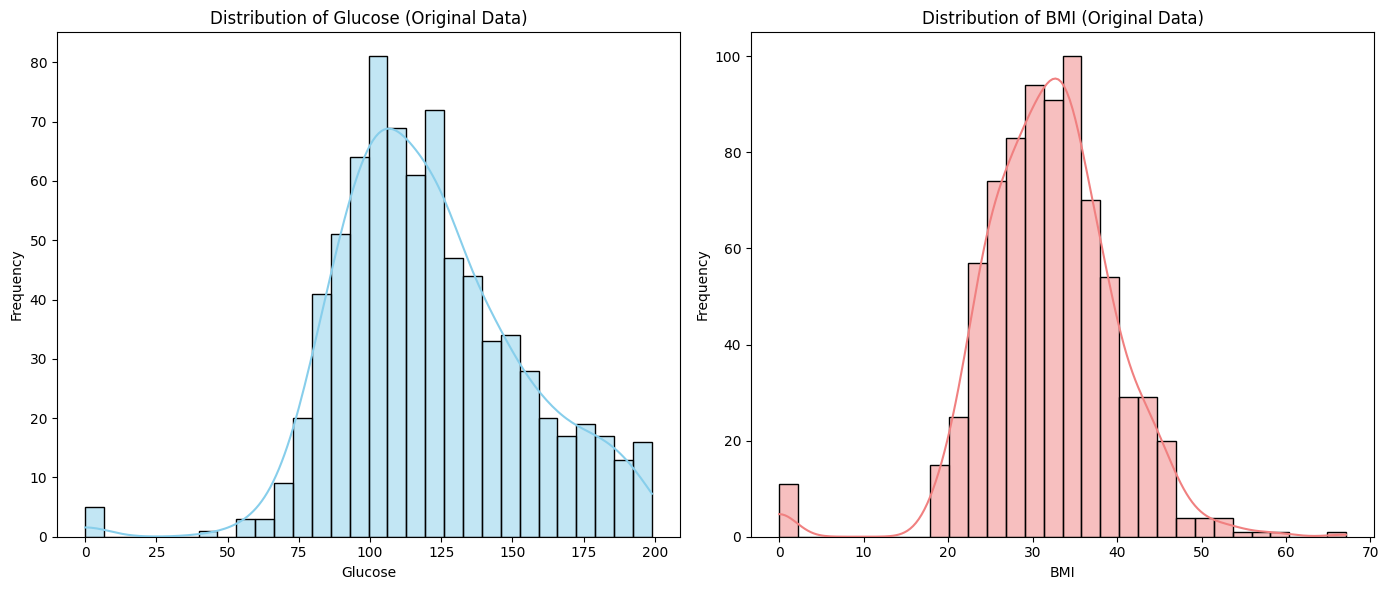

In [60]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Glucose'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Glucose (Original Data)')
plt.xlabel('Glucose')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df['BMI'], kde=True, bins=30, color='lightcoral')
plt.title('Distribution of BMI (Original Data)')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Comparison with SVM
SVM is a short form of Support Vector machine which is supervised machine learning model.Used for classification and regression tasks. Here SVM is used as a classification model. Basically linear SVM has been used here.
 **Hyperparameter Tuning**
 **Regularization Parameter (C)**: Controls the trade-off between maximizing the margin and minimizing classification errors. A high C prioritizes classifying all training points correctly (risking a narrow margin and overfitting), while a low C prioritizes a wider margin, allowing some misclassified points for better generalization.


 **Gamma (γ)**: Explicitly used with non-linear kernels like RBF. A high gamma means only points close to the boundary are considered, leading to a highly complex, tightly fit boundary. A low gamma considers points further away, leading to a smoother decision boundary.

In [61]:
from sklearn.svm import SVC as sv
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix



In [62]:
model1= sv()
model1.fit=(X_train_smote, y_train_smote)

In [63]:
param_grid = {'C': [0.1, 1, 10, ],
			'gamma': [1, 0.1, 0.01, ],
			'kernel': ['linear']}


In [64]:
grid= GridSearchCV(sv(),param_grid,refit=True,verbose=2)

In [65]:
grid.fit(X_train_smote, y_train_smote)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.4s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.4s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.3s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.3s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.3s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.4s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.4s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.3s
[CV] END ...................C=0.1, gamma=0.01, kernel=linear; total time=   0.2s
[CV] END ...................C=0.1, gamma=0.01, ke

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01],
                         'kernel': ['linear']},
             verbose=2)

In [66]:
print(grid.best_params_)

{'C': 10, 'gamma': 1, 'kernel': 'linear'}


In [67]:
print(grid.best_estimator_)

SVC(C=10, gamma=1, kernel='linear')


In [76]:
grid_predictions = grid.best_estimator_.predict(x_test)
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))


[[68 31]
 [15 40]]
              precision    recall  f1-score   support

           0       0.82      0.69      0.75        99
           1       0.56      0.73      0.63        55

    accuracy                           0.70       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.70      0.71       154



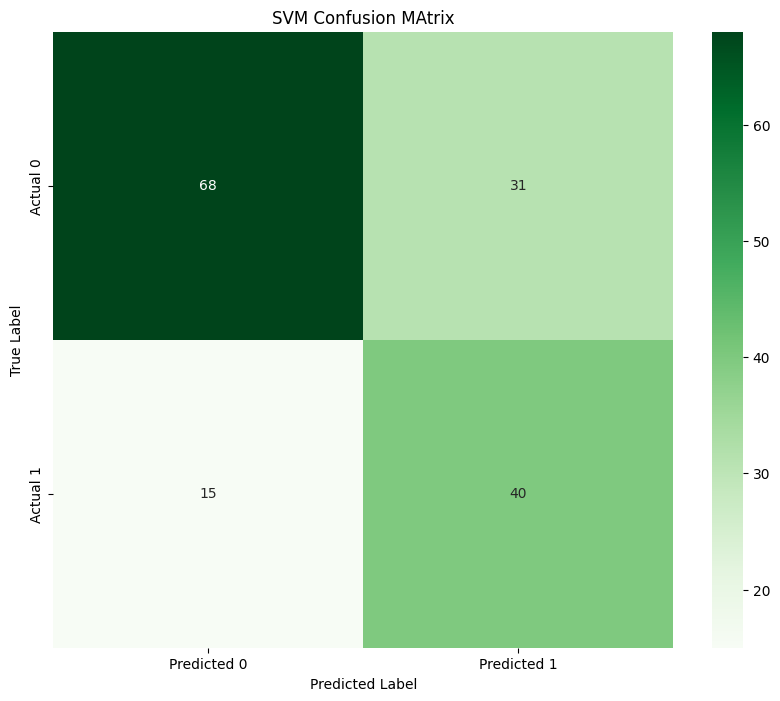

In [81]:
#Plot confusion_matrix
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, grid_predictions), annot=True, fmt="d", cmap="Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels= ['Actual 0', 'Actual 1'] )

plt.title('SVM Confusion MAtrix')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [82]:
#Comparing SVM with LR


### Comparison of Classification Reports

Here are the classification reports for the Logistic Regression model (after SMOTE) and the SVM model (tuned with GridSearchCV). Let's compare their performance, especially focusing on recall for class 1 (diabetes), which was our primary goal for improvement.

In [84]:
print('--- Logistic Regression (after SMOTE) ---')
print(classification_report(y_test, y_pred_smote))

print('\n--- SVM (tuned with GridSearchCV) ---')
print(classification_report(y_test, grid_predictions))

--- Logistic Regression (after SMOTE) ---
              precision    recall  f1-score   support

           0       0.81      0.69      0.74        99
           1       0.56      0.71      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.70      0.68       154
weighted avg       0.72      0.69      0.70       154


--- SVM (tuned with GridSearchCV) ---
              precision    recall  f1-score   support

           0       0.82      0.69      0.75        99
           1       0.56      0.73      0.63        55

    accuracy                           0.70       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.70      0.71       154



In [85]:
from sklearn.metrics import roc_curve,auc

In [88]:
#Calulate the ROC for both model
fpr, tpr, thresholds = roc_curve(y_test, y_pred_smote)
roc_auc = auc(fpr, tpr)
fpr1,tpr1,thresholds1=roc_curve(y_test,grid_predictions)
roc_auc1=auc(fpr1,tpr1)


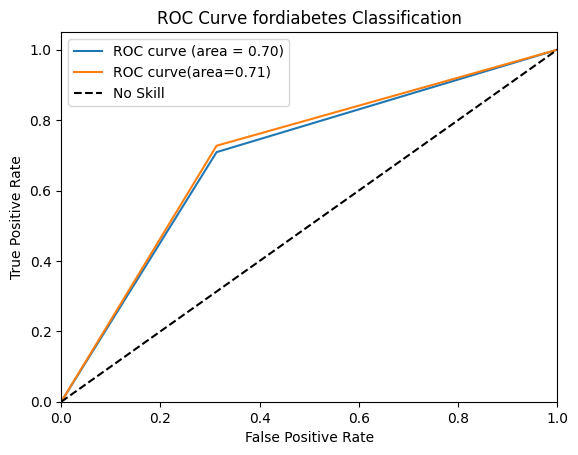

In [90]:
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot(fpr1,tpr1,label='ROC curve(area=%0.2f)'% roc_auc1)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve fordiabetes Classification')
plt.legend()
plt.show()

# Comparison with XGBoost

In [95]:
import xgboost as xgb
from xgboost import XGBClassifier



In [93]:
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}


In [97]:
model2=XGBClassifier(**params)
model2.fit(X_train_smote, y_train_smote)

XGBClassifier(alpha=10, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

In [99]:
y_pred_xgb=model2.predict(x_test)
print(classification_report(y_test,y_pred_xgb))


              precision    recall  f1-score   support

           0       0.84      0.72      0.77        99
           1       0.59      0.75      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.73       154



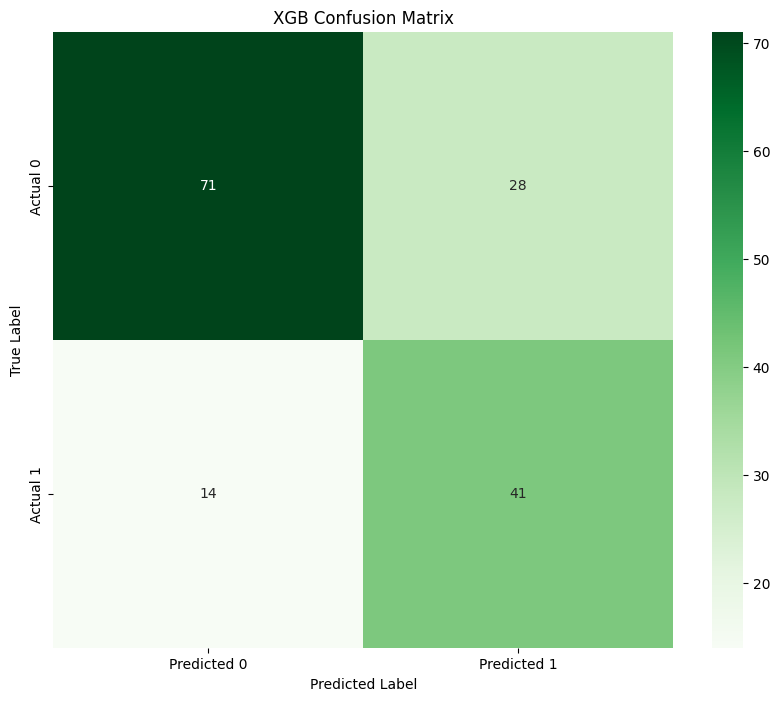

In [102]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test,y_pred_xgb), annot= True , fmt="d" , cmap= "Greens",xticklabels=["Predicted 0", "Predicted 1"],yticklabels= ['Actual 0', 'Actual 1'] )
plt.title("XGB Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Comprehensive Model Comparison: Logistic Regression, SVM, and XGBoost

Let's bring together the classification reports for all three models to get a clearer picture of their comparative performance, especially regarding the identification of class 1 (diabetes).

In [103]:
print('--- Logistic Regression (after SMOTE) ---')
print(classification_report(y_test, y_pred_smote))

print('\n--- SVM (tuned with GridSearchCV) ---')
print(classification_report(y_test, grid_predictions))

print('\n--- XGBoost Classifier ---')
print(classification_report(y_test, y_pred_xgb))

--- Logistic Regression (after SMOTE) ---
              precision    recall  f1-score   support

           0       0.81      0.69      0.74        99
           1       0.56      0.71      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.70      0.68       154
weighted avg       0.72      0.69      0.70       154


--- SVM (tuned with GridSearchCV) ---
              precision    recall  f1-score   support

           0       0.82      0.69      0.75        99
           1       0.56      0.73      0.63        55

    accuracy                           0.70       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.70      0.71       154


--- XGBoost Classifier ---
              precision    recall  f1-score   support

           0       0.84      0.72      0.77        99
           1       0.59      0.75      0.66        55

    accuracy                           0.73       154
   macro avg       

#### Comparative Analysis:

Looking at the classification reports for all three models, we can make the following observations, with a continued focus on **recall for class 1 (diabetes)**:

*   **Logistic Regression (after SMOTE):**
    *   **Recall (Class 1):** 0.71
    *   **Precision (Class 1):** 0.56
    *   **Accuracy:** 0.69

*   **SVM (tuned with GridSearchCV):**
    *   **Recall (Class 1):** 0.73
    *   **Precision (Class 1):** 0.56
    *   **Accuracy:** 0.70

*   **XGBoost Classifier:**
    *   **Recall (Class 1):** 0.75
    *   **Precision (Class 1):** 0.59
    *   **Accuracy:** 0.73

**Key Findings:**

1.  **XGBoost has the highest Recall for Class 1 (Diabetes):** At 0.75, XGBoost is the best performing model in terms of identifying actual diabetes cases. This is crucial for a medical diagnosis task, where minimizing false negatives is often a high priority.
2.  **XGBoost also shows improved Precision for Class 1:** With a precision of 0.59, XGBoost is slightly better at correctly classifying positive predictions compared to Logistic Regression and SVM (both 0.56). This means it generates slightly fewer false positives.
3.  **Overall Accuracy:** XGBoost also leads in overall accuracy (0.73), indicating a more balanced performance across both classes.
4.  **SVM vs. Logistic Regression:** SVM (tuned) showed a marginal improvement in recall for class 1 over Logistic Regression, but both were outperfomed by XGBoost.

**Conclusion:**

Based on these metrics, the **XGBoost Classifier appears to be the most effective model** for this diabetes prediction task, particularly because it achieves the highest recall for the positive class (diabetes) while also improving precision and overall accuracy. This indicates it is better at correctly identifying individuals with diabetes and makes fewer incorrect positive predictions compared to the other models.